In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

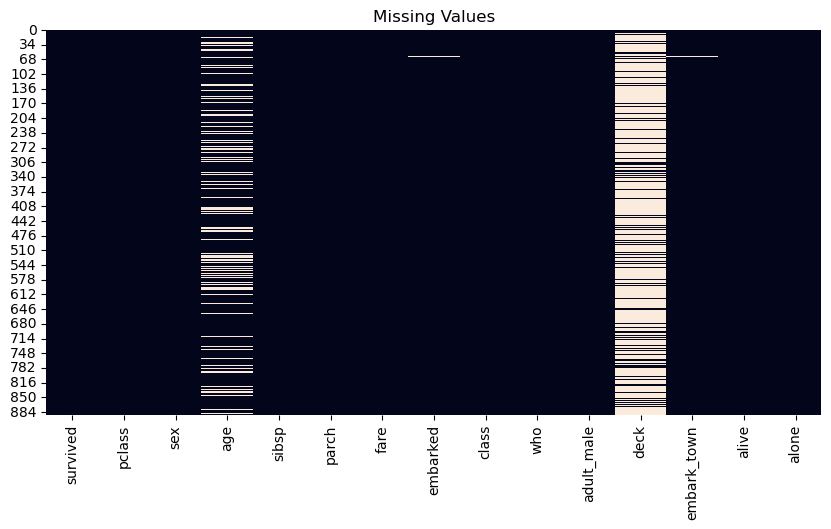

In [7]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values")

plt.show()

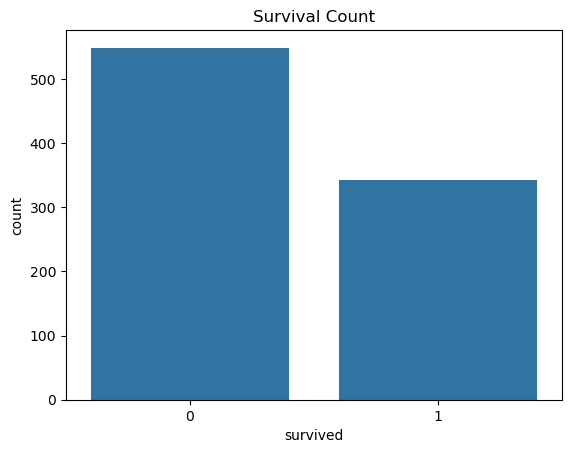

In [8]:
sns.countplot(x="survived", data=df)

plt.title("Survival Count")

plt.show()

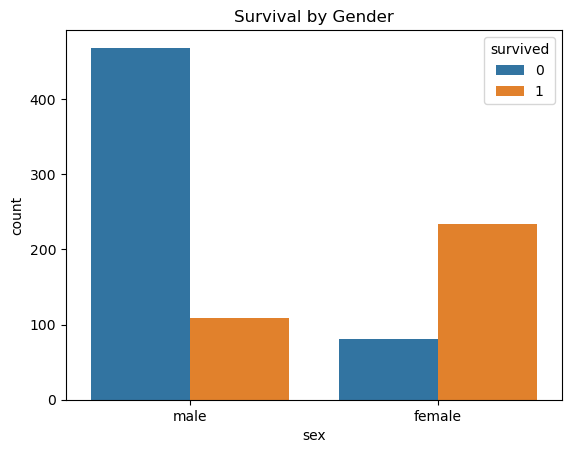

In [9]:
sns.countplot(x="sex", hue="survived", data=df)

plt.title("Survival by Gender")

plt.show()

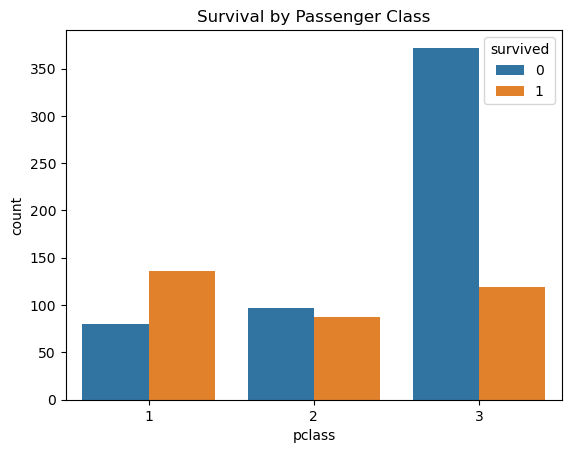

In [10]:
sns.countplot(x="pclass", hue="survived", data=df)

plt.title("Survival by Passenger Class")

plt.show()

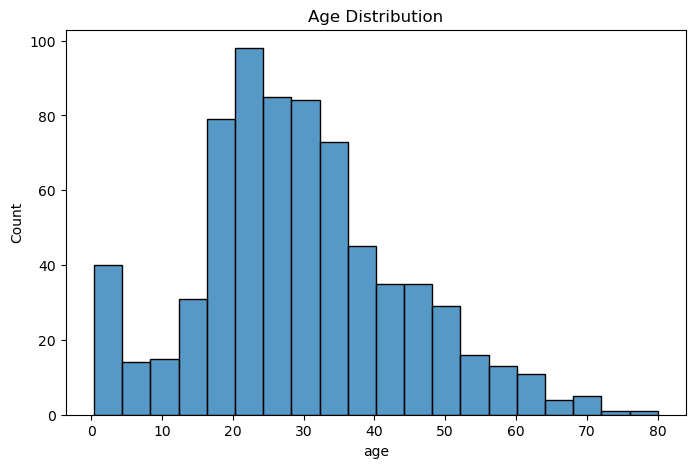

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=20)

plt.title("Age Distribution")

plt.show()

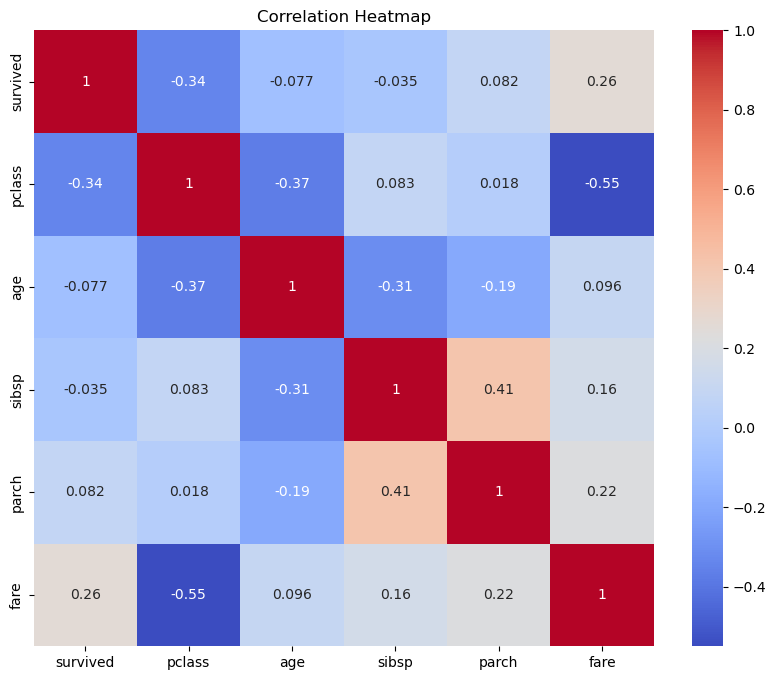

In [12]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [13]:
df["age"] = df["age"].fillna(df["age"].median())

In [14]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

In [15]:
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

In [16]:
df = df.drop(columns=["deck"])

In [17]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [18]:
df["family_size"] = df["sibsp"] + df["parch"] + 1

In [19]:
df["is_alone"] = (df["family_size"] == 1).astype(int)

In [20]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size,is_alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,2,0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,2,0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,1,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,2,0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,1,1


In [21]:
df["sex"] = df["sex"].map({"male":0,"female":1})

df["embarked"] = df["embarked"].map({
    "S":0,
    "C":1,
    "Q":2
})

df["class"] = df["class"].map({
    "First":1,
    "Second":2,
    "Third":3
})

df["who"] = df["who"].map({
    "man":0,
    "woman":1,
    "child":2
})

df["adult_male"] = df["adult_male"].astype(int)

df["alone"] = df["alone"].astype(int)

In [22]:
X = df[
[
"pclass",
"sex",
"age",
"sibsp",
"parch",
"fare",
"embarked",
"family_size",
"is_alone"
]
]

y = df["survived"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(

X,
y,

test_size=0.2,

random_state=42
)

In [24]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [25]:
lr_pred = lr.predict(X_test)

In [26]:
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.7988826815642458


In [27]:
print(confusion_matrix(y_test, lr_pred))

[[90 15]
 [21 53]]


In [28]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [29]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
rf_pred = rf.predict(X_test)

In [31]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8212290502793296


In [32]:
print(confusion_matrix(y_test, rf_pred))

[[90 15]
 [17 57]]


In [33]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       105
           1       0.79      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [34]:
print("Logistic Regression Accuracy :", lr_accuracy)

print("Random Forest Accuracy :", rf_accuracy)

Logistic Regression Accuracy : 0.7988826815642458
Random Forest Accuracy : 0.8212290502793296


In [35]:
df.to_csv(r"D:\AIML Assignments\Week-1\Question-5\titanic.csv", index=False)